# Reverse Time Migration (RTM) - Scalar Wave Playground

This notebook implements a test of a Reverse Time Migration (RTM) scheme. To begin, we focus on a simple 2D damped scalar wave equation (Transverse Electric mode) to reduce computational complexity.

## 1. Environment Setup

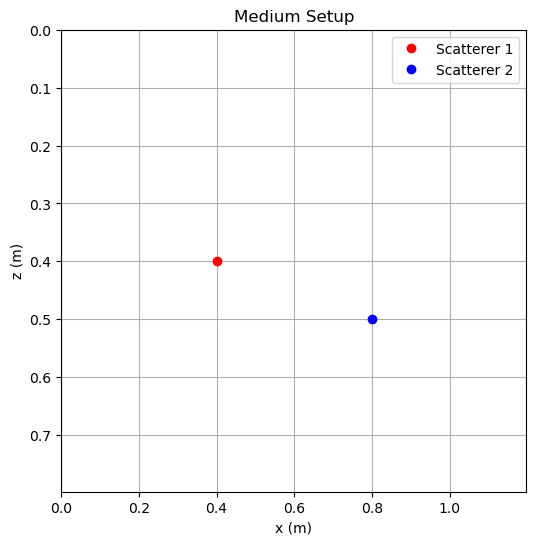

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Domain parameters
nx, nz = 600, 400
dx, dz = 0.002, 0.002 # 2 mm resolution
x = np.arange(nx) * dx
z = np.arange(nz) * dz
X, Z = np.meshgrid(x, z)

# PEC cylinder locations
scatterers = [(0.4, 0.4), (0.8, 0.5)]

# Plot setup
plt.figure(figsize=(6, 6))
plt.plot(scatterers[0][0], scatterers[0][1], 'ro', label='Scatterer 1')
plt.plot(scatterers[1][0], scatterers[1][1], 'bo', label='Scatterer 2')
plt.xlim(0, max(x))
plt.ylim(max(z), 0)
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.title('Medium Setup')
plt.legend()
plt.grid(True)
plt.show()

## 2 & 3. Scalar Wave Solver & Two-Way Survey Model

We now implement a full two-way survey model. We will place a point source at the center of the top domain (surface) acting like a seismic "shot", which propagates downwards, scatters off physical perturbations, and travels back up to a line of receivers arrayed across the surface.

In [17]:
# Physical constants
c0 = 3e8
epsilon0 = 8.854e-12
mu0 = 4 * np.pi * 1e-7

# Background Setup
epsilon = np.ones((nz, nx)) * epsilon0
mu = np.ones((nz, nx)) * mu0
sigma = np.zeros((nz, nx))

# Add Physical Scatterers (Dielectric/Conductivity Contrast)
for (sx, sz) in scatterers:
    ix, iz = int(sx / dx), int(sz / dz)
    # Create small scattering objects (radius 3 grid points)
    radius = 3
    for i in range(-radius, radius + 1):
        for j in range(-radius, radius + 1):
            if i**2 + j**2 <= radius**2:
                if 0 <= iz+i < nz and 0 <= ix+j < nx:
                    # Let's use severe conductivity to create strong reflections
                    sigma[iz+i, ix+j] = 0.5 

v_max = 1 / np.sqrt(epsilon0 * mu0)

# CFL Condition
dt = 0.99 * 1 / (v_max * np.sqrt(1/dx**2 + 1/dz**2))
# Increased time steps drastically for two-way travel (down and back)
nt = 1500 
time = np.arange(nt) * dt

# Ricker Wavelet Source 
fc = 1.5e9 # 1.5 GHz
t0 = 1.2 / fc
src_wavelet = (1 - 2*(np.pi*fc*(time - t0))**2) * np.exp(-(np.pi*fc*(time - t0))**2)

# Absorbing boundary conditions - Conductivity Sponge Profile
# Instead of multiplying E_next with a damping array (which causes numerical reflections), 
# we integrate an absorbing conductivity profile directly into the FDTD coefficients.
npad = 60
sigma_sponge = np.zeros((nz, nx))
sigma_max = 5.0 # Max conductivity at boundaries
for i in range(npad):
    val = sigma_max * ((npad - i) / npad)**3 # Cubic ramp up
    sigma_sponge[i, :] = np.maximum(sigma_sponge[i, :], val)
    sigma_sponge[-i-1, :] = np.maximum(sigma_sponge[-i-1, :], val)
    sigma_sponge[:, i] = np.maximum(sigma_sponge[:, i], val)
    sigma_sponge[:, -i-1] = np.maximum(sigma_sponge[:, -i-1], val)

# Total effective conductivity for equation
sigma_total = sigma + sigma_sponge

# Coefficients for FDTD
# Now correctly using physical conductivity for absorption rather than a numerical multiplier hack
A = epsilon * mu / dt**2 + mu * sigma_total / (2*dt)
B = 2 * epsilon * mu / dt**2
C = epsilon * mu / dt**2 - mu * sigma_total / (2*dt)
D = 1 / dx**2
E_coef = 1 / dz**2

## 4. Forward Propagation

Run forward simulation, save wavefield snapshots, and generate synthetic B-scan data along a receiver line at surface `z = 0` (or `z=pad`).

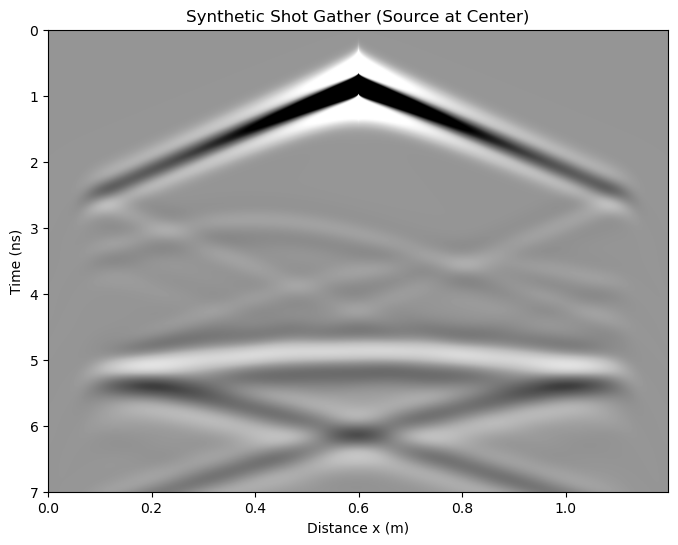

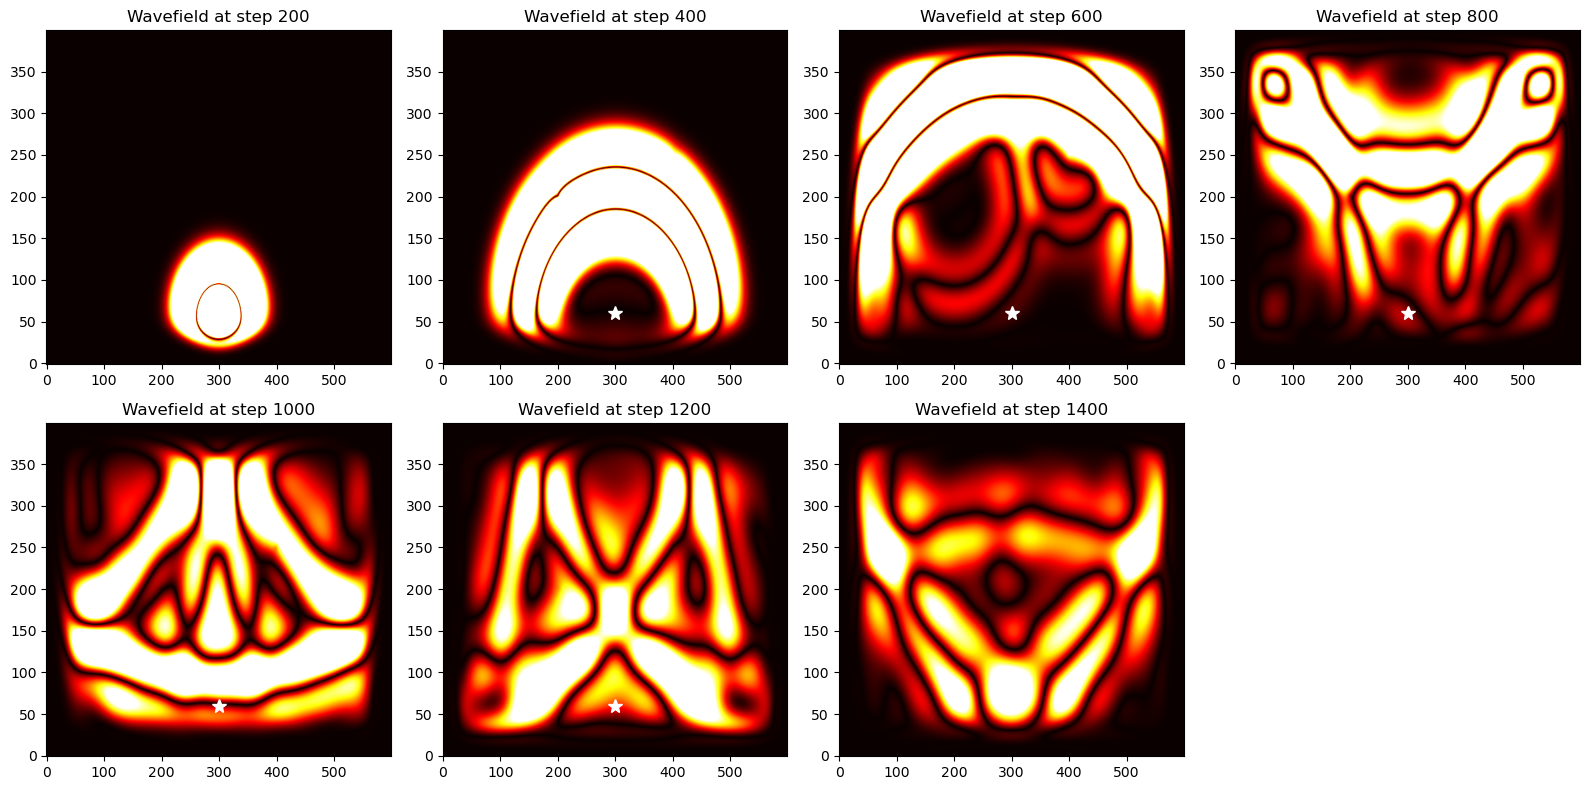

In [18]:
E_prev = np.zeros((nz, nx))
E_curr = np.zeros((nz, nx))
E_next = np.zeros((nz, nx))

# Source location (Top Center)
src_x = nx // 2
src_z = npad 

# Synthetic B-scan (Receivers at surface just below ABC pad)
rec_z = npad 
bscan = np.zeros((nt, nx))

forward_snapshots = []
snap_times = [200, 400, 600, 800, 1000, 1200, 1400]

for n in range(nt):
    # Spatial derivatives
    d2E_dx2 = np.zeros_like(E_curr)
    d2E_dz2 = np.zeros_like(E_curr)
    d2E_dx2[:, 1:-1] = (E_curr[:, 2:] - 2*E_curr[:, 1:-1] + E_curr[:, :-2]) * D
    d2E_dz2[1:-1, :] = (E_curr[2:, :] - 2*E_curr[1:-1, :] + E_curr[:-2, :]) * E_coef
    
    # Update equation
    E_next = (d2E_dx2 + d2E_dz2 + B * E_curr - C * E_prev) / A
    
    # Source condition (Inject wavelet at surface point)
    E_next[src_z, src_x] += src_wavelet[n] / A[src_z, src_x] * (1 / (dx*dz))
    
    # Hard Dirichlet boundaries
    E_next[0, :] = 0; E_next[-1, :] = 0
    E_next[:, 0] = 0; E_next[:, -1] = 0
        
    E_prev[:] = E_curr[:]
    E_curr[:] = E_next[:]
    
    # Record B-scan (receiver array)
    bscan[n, :] = E_curr[rec_z, :]
    
    if n in snap_times:
        forward_snapshots.append(E_curr.copy())

# Visualizing B-scan and forward wavefields
fig, ax1 = plt.subplots(figsize=(8, 6))
extent = [0, max(x), max(time)*1e9, 0]
vmax = np.max(np.abs(bscan)) * 0.05 
im = ax1.imshow(bscan, aspect='auto', cmap='Greys', extent=extent, vmin=-vmax, vmax=vmax)
ax1.set_title('Synthetic Shot Gather (Source at Center)')
ax1.set_xlabel('Distance x (m)')
ax1.set_ylabel('Time (ns)')
plt.show()

num_snaps = len(snap_times)
cols = 4
rows = (num_snaps + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, (snap, t_step) in enumerate(zip(forward_snapshots, snap_times)):
    ax = axes[i]
    vmax_snap = np.max(np.abs(forward_snapshots[1])) * 0.1 # Lock color scaling to early wave
    ax.imshow(np.abs(snap), aspect='auto', cmap='hot', vmax=vmax_snap)
    ax.set_title(f'Wavefield at step {t_step}')
    ax.plot(src_x, src_z, 'w*', markersize=10) # Show source
    ax.invert_yaxis()

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 5 & 6. Backward Propagation and Imaging

Perform backward extrapolation by injecting the recorded data into the grid in reverse time order and apply a zero-time imaging condition.

In [19]:
E_prev_bw = np.zeros((nz, nx))
E_curr_bw = np.zeros((nz, nx))
E_next_bw = np.zeros((nz, nx))

# Image grid
Image = np.zeros((nz, nx))

backward_snapshots = []

# Time step where the Ricker wavelet peaks
n_focus = int(t0 / dt)

for n in range(nt-1, -1, -1):
    # Inject recorded data at receiver locations (acting as sources for backward propagation)
    E_curr_bw[rec_z, :] += bscan[n, :] * damping[rec_z, :]

    # Spatial derivatives
    d2E_dx2 = np.zeros_like(E_curr_bw)
    d2E_dz2 = np.zeros_like(E_curr_bw)
    d2E_dx2[:, 1:-1] = (E_curr_bw[:, 2:] - 2*E_curr_bw[:, 1:-1] + E_curr_bw[:, :-2]) * D
    d2E_dz2[1:-1, :] = (E_curr_bw[2:, :] - 2*E_curr_bw[1:-1, :] + E_curr_bw[:-2, :]) * E_coef
    
    E_next_bw = (d2E_dx2 + d2E_dz2 + B * E_curr_bw - C * E_prev_bw) / A
    
    # Damping & Boundaries
    E_next_bw *= damping
    E_next_bw[0, :] = 0; E_next_bw[-1, :] = 0
    E_next_bw[:, 0] = 0; E_next_bw[:, -1] = 0
    
    # Imaging Condition (Exploding reflector focuses at the peak wavelet departure time t0)
    if n == n_focus:
        Image = E_curr_bw.copy()
    
    # Store snapshots 
    if n in snap_times:
        backward_snapshots.append(E_curr_bw.copy())
        
    E_prev_bw[:] = E_curr_bw[:]
    E_curr_bw[:] = E_next_bw[:]

fig, ax = plt.subplots(figsize=(8, 6))
# Focus display by plotting magnitude since the focused wavefield could have inverted polarity
im = ax.imshow(np.abs(Image), aspect='auto', cmap='hot', extent=[0, max(x), max(z), 0], vmax=np.max(np.abs(Image))*0.5)
ax.plot(scatterers[0][0], scatterers[0][1], 'w+', markersize=15, label='True Scat 1')
ax.plot(scatterers[1][0], scatterers[1][1], 'cx', markersize=15, label='True Scat 2')
ax.set_title('RTM Migrated Image (Exploding Reflector)')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
plt.legend()
plt.colorbar(im, ax=ax, label='Absolute Amplitude')
plt.show()

NameError: name 'damping' is not defined